Import básicos

In [ ]:
!pip install h5py

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import h5py

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from copy import deepcopy

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cpu')

Importar dataset

In [ ]:
from google.colab import files

uploaded = files.upload()

mat_path = "/content/Dataset_completo.mat"

with h5py.File(mat_path, "r") as f:
    print("Claves del archivo:", list(f.keys()))
    Data_main = np.array(f["Data_main"]).T

Data_main.shape


Saving Dataset_completo.mat to Dataset_completo.mat
Claves del archivo: ['#refs#', '#subsystem#', 'Data_main', 'Info_aux']


(368928, 7)

Construir df con columnas físicas(las caracteristicas de la capa limite) + side + position

In [ ]:

df = pd.DataFrame(Data_main, columns=["Ue", "dcpdx", "delta", "tau_w", "Tu_BL", "freq", "spec"])

N = len(df)
print("Filas totales:", N)

# position = 1-6 repetido
df["position"] = np.tile(np.arange(1, 7), N // 6)

# side: bloques de 6 (Lado de presión - Lado de succión)
df["side"] = np.array(["P" if (i // 6) % 2 == 0 else "S" for i in range(N)])

df.head(12)


Filas totales: 368928


,Ue,dcpdx,delta,tau_w,Tu_BL,freq,spec,position,side
0,11.2016,1.888570,0.000909,0.773955,10.0,104.0,39.812235,1,P
1,11.4228,-0.428764,0.001189,0.484671,10.0,104.0,37.597360,2,P
2,11.1298,0.224612,0.002449,0.391143,10.0,104.0,23.978938,3,P
3,10.6913,0.285759,0.004297,0.320276,10.0,104.0,0.035554,4,P
4,10.3171,0.330400,0.006093,0.269133,10.0,104.0,5.706164,5,P
5,9.6298,1.459712,0.008597,0.187731,10.0,104.0,6.597887,6,P
6,11.4894,-1.307672,0.000817,0.773955,10.0,104.0,38.247120,1,S
7,11.1837,1.420687,0.001241,0.484671,10.0,104.0,37.654597,2,S
8,11.0955,-0.245605,0.002439,0.391143,10.0,104.0,27.943913,3,S
9,10.6996,0.219550,0.004273,0.320276,10.0,104.0,-3.069968,4,S


Codificar side/posición y preparar features/target (lineal)

In [ ]:
# side_code: P=0, S=1
df["side_code"] = (df["side"] == "S").astype(float)

# pos_norm: 1..6 -> 0..1
df["pos_norm"] = (df["position"] - 1) / 5.0

# Escala lineal
target_col = "spec"

# Features
feature_cols = ["Ue", "dcpdx", "delta", "tau_w", "Tu_BL", "freq",
                "side_code", "pos_norm"]

X = df[feature_cols].values.astype(np.float32)
y = df[target_col].values.astype(np.float32)

print("X shape:", X.shape)
print("y shape:", y.shape)

# Split: train / valid / test
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.15, random_state=42
)

print("Train :", X_train.shape[0])
print("Valid :", X_val.shape[0])
print("Test  :", X_test.shape[0])

# Escalado SOLO de X
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train).astype(np.float32)
X_val_scaled   = scaler.transform(X_val).astype(np.float32)
X_test_scaled  = scaler.transform(X_test).astype(np.float32)


X shape: (368928, 8)
y shape: (368928,)
Train : 266549
Valid : 47039
Test  : 55340


Dataset y dataloaders

In [ ]:
class SpecDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).view(-1, 1)

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_ds = SpecDataset(X_train_scaled, y_train)
val_ds   = SpecDataset(X_val_scaled,   y_val)
test_ds  = SpecDataset(X_test_scaled,  y_test)

train_loader = DataLoader(train_ds, batch_size=1024, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=2048, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=2048, shuffle=False)


Definir el MLP y entrenar

In [ ]:
input_dim = X_train_scaled.shape[1]

class MLP(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x)

model = MLP(input_dim).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

n_epochs = 80
best_val_loss = np.inf
patience = 10
patience_cnt = 0
best_state = None

for epoch in range(1, n_epochs + 1):
    # --- TRAIN ---
    model.train()
    train_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * xb.size(0)
    train_loss /= len(train_ds)

    # --- VALID ---
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            preds = model(xb)
            loss = criterion(preds, yb)
            val_loss += loss.item() * xb.size(0)
    val_loss /= len(val_ds)

    print(f"[LINEAL] Epoch {epoch:03d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    # Early stopping
    if val_loss < best_val_loss - 1e-4:
        best_val_loss = val_loss
        best_state = deepcopy(model.state_dict())
        patience_cnt = 0
    else:
        patience_cnt += 1
        if patience_cnt >= patience:
            print("[LINEAL] Early stopping!")
            break

# cargar mejores pesos
if best_state is not None:
    model.load_state_dict(best_state)


[LINEAL] Epoch 001 | Train Loss: 71.4907 | Val Loss: 26.9817
[LINEAL] Epoch 002 | Train Loss: 22.6534 | Val Loss: 13.0549
[LINEAL] Epoch 003 | Train Loss: 15.1263 | Val Loss: 9.1755
[LINEAL] Epoch 004 | Train Loss: 11.8347 | Val Loss: 7.5002
[LINEAL] Epoch 005 | Train Loss: 10.1575 | Val Loss: 6.2075
[LINEAL] Epoch 006 | Train Loss: 8.8332 | Val Loss: 5.6214
[LINEAL] Epoch 007 | Train Loss: 7.8906 | Val Loss: 4.8603
[LINEAL] Epoch 008 | Train Loss: 7.1908 | Val Loss: 4.7976
[LINEAL] Epoch 009 | Train Loss: 6.6046 | Val Loss: 4.0430
[LINEAL] Epoch 010 | Train Loss: 6.1138 | Val Loss: 3.7853
[LINEAL] Epoch 011 | Train Loss: 5.6832 | Val Loss: 3.9488
[LINEAL] Epoch 012 | Train Loss: 5.3638 | Val Loss: 3.3710
[LINEAL] Epoch 013 | Train Loss: 5.1298 | Val Loss: 3.3893
[LINEAL] Epoch 014 | Train Loss: 4.9006 | Val Loss: 3.0840
[LINEAL] Epoch 015 | Train Loss: 4.7124 | Val Loss: 2.9830
[LINEAL] Epoch 016 | Train Loss: 4.5282 | Val Loss: 3.1239
[LINEAL] Epoch 017 | Train Loss: 4.4135 | Val Los

Métricas en TEST (R², RMSE, MAE)

In [ ]:
model.eval()
y_test_pred = []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        preds = model(xb).cpu().numpy().ravel()
        y_test_pred.append(preds)

y_test_pred = np.concatenate(y_test_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
mae  = mean_absolute_error(y_test, y_test_pred)
R2   = r2_score(y_test, y_test_pred)

print("RESULTADOS TEST (MLP global LINEAL)")
print(f"LINEAL: R2={R2:.4f} | RMSE={rmse:.4f} | MAE={mae:.4f}")


RESULTADOS TEST (MLP global LINEAL)
LINEAL: R2=0.9903 | RMSE=1.2461 | MAE=0.7121


Probar el modelo

In [ ]:

import numpy as np
import torch


def predict_spec(Ue, dcpdx, delta, tau_w, Tu_BL, freq, side_str, position):
    """
    Devuelve la predicción del espectro (spec) del modelo MLP entrenado.
    Todo en escala lineal (igual que la columna 7 del dataset).
    """

    # side -> side_code
    side_code = 0.0 if side_str.upper() == "P" else 1.0

    # position -> pos_norm
    pos_norm = (position - 1) / 5.0

    # Vector con el orden correcto de features
    x = np.array([[Ue, dcpdx, delta, tau_w, Tu_BL, freq, side_code, pos_norm]],
                 dtype=np.float32)

    # Normalizar con el mismo scaler del entrenamiento
    x_scaled = scaler.transform(x).astype(np.float32)

    # Convertir a tensor y enviarlo al dispositivo
    x_tensor = torch.tensor(x_scaled, dtype=torch.float32).to(device)

    # Predicción del modelo
    model.eval()
    with torch.no_grad():
        y_pred = model(x_tensor).cpu().numpy().ravel()[0]

    return float(y_pred)

#PREDICCIÓN MANUAL


print("Resultado manual")
spec_pred = predict_spec(
    Ue=11.2016,
    dcpdx=1.8886,
    delta=0.0009086735,
    tau_w=0.7740,
    Tu_BL=20,
    freq=104,
    side_str="P",
    position=1
)

print("Predicción", spec_pred)


# FILA DEL DATAFRAME


print("resultado con una fila del dataframe")
row = df.iloc[158500]

spec_pred_row = predict_spec(
    Ue=row["Ue"],
    dcpdx=row["dcpdx"],
    delta=row["delta"],
    tau_w=row["tau_w"],
    Tu_BL=row["Tu_BL"],
    freq=row["freq"],
    side_str=row["side"],
    position=int(row["position"])
)

print("Real      :", row["spec"])
print("Predicho  :", spec_pred_row)





Resultado manual
Predicción 47.28617858886719
resultado con una fila del dataframe
Real      : 9.838178270644642
Predicho  : 9.534979820251465


**Segunda parte del código **


Subir Info_aux para complementar el dataframe

In [ ]:
from google.colab import files
uploaded = files.upload()

import pandas as pd

fname = list(uploaded.keys())[0]
print("Archivo subido:", fname)

df_excel = pd.read_csv(fname)

print("shape:", df_excel.shape)
df_excel.head()

print(df_excel.columns)
print(df_excel.head(3))



Saving Info_aux.csv to Info_aux.csv
Archivo subido: Info_aux.csv
shape: (368928, 7)
Index(['filename_diff', 'geometry', 'AoA', 'U', 'Tu', 'side', 'position'], dtype='object')
              filename_diff geometry  AoA   U  Tu side  position
0  Tu10_AoA+00_U10_diff.mat    NoSPM    0  10  10    P         1
1  Tu10_AoA+00_U10_diff.mat    NoSPM    0  10  10    P         2
2  Tu10_AoA+00_U10_diff.mat    NoSPM    0  10  10    P         3


Dataframe con nombres de archivo



In [ ]:

print("df shape:", df.shape)
print("df_excel shape:", df_excel.shape)

n = min(len(df), len(df_excel))
df = df.iloc[:n].reset_index(drop=True)
df_excel = df_excel.iloc[:n].reset_index(drop=True)

df_full = pd.concat([df, df_excel], axis=1)

print("df_full shape:", df_full.shape)
df_full.head(12)


df shape: (368928, 11)
df_excel shape: (368928, 7)
df_full shape: (368928, 18)


,Ue,dcpdx,delta,tau_w,Tu_BL,freq,spec,position,side,side_code,pos_norm,filename_diff,geometry,AoA,U,Tu,side,position
0,11.2016,1.888570,0.000909,0.773955,10.0,104.0,39.812235,1,P,0.0,0.0,Tu10_AoA+00_U10_diff.mat,NoSPM,0,10,10,P,1
1,11.4228,-0.428764,0.001189,0.484671,10.0,104.0,37.597360,2,P,0.0,0.2,Tu10_AoA+00_U10_diff.mat,NoSPM,0,10,10,P,2
2,11.1298,0.224612,0.002449,0.391143,10.0,104.0,23.978938,3,P,0.0,0.4,Tu10_AoA+00_U10_diff.mat,NoSPM,0,10,10,P,3
3,10.6913,0.285759,0.004297,0.320276,10.0,104.0,0.035554,4,P,0.0,0.6,Tu10_AoA+00_U10_diff.mat,NoSPM,0,10,10,P,4
4,10.3171,0.330400,0.006093,0.269133,10.0,104.0,5.706164,5,P,0.0,0.8,Tu10_AoA+00_U10_diff.mat,NoSPM,0,10,10,P,5
5,9.6298,1.459712,0.008597,0.187731,10.0,104.0,6.597887,6,P,0.0,1.0,Tu10_AoA+00_U10_diff.mat,NoSPM,0,10,10,P,6
6,11.4894,-1.307672,0.000817,0.773955,10.0,104.0,38.247120,1,S,1.0,0.0,Tu10_AoA+00_U10_diff.mat,NoSPM,0,10,10,S,1
7,11.1837,1.420687,0.001241,0.484671,10.0,104.0,37.654597,2,S,1.0,0.2,Tu10_AoA+00_U10_diff.mat,NoSPM,0,10,10,S,2
8,11.0955,-0.245605,0.002439,0.391143,10.0,104.0,27.943913,3,S,1.0,0.4,Tu10_AoA+00_U10_diff.mat,NoSPM,0,10,10,S,3
9,10.6996,0.219550,0.004273,0.320276,10.0,104.0,-3.069968,4,S,1.0,0.6,Tu10_AoA+00_U10_diff.mat,NoSPM,0,10,10,S,4


In [ ]:
def inspect_row(i):
    r = df_full.iloc[i]

    print(f"\n FILA {i} ")

    for col in ["filename_diff","geometry","AoA","U","Tu","side","position"]:
        if col in df_full.columns:
            print(f"{col:12s}: {r[col]}")
        elif f"infoaux_{col}" in df_full.columns:
            print(f"{col:12s}: {r[f'infoaux_{col}']}")

    for col in ["Ue","dcpdx","delta","tau_w","Tu_BL","freq","spec"]:
        if col in df_full.columns:
            print(f"{col:12s}: {r[col]}")

# Insertar fila
inspect_row(158500)


 FILA 158500 
filename_diff: Tu10_SPM_AoA+20_U30_diff.mat
geometry    : SPM
AoA         : 20
U           : 30
Tu          : 10
side        : side    P
side    P
Name: 158500, dtype: object
position    : position    5
position    5
Name: 158500, dtype: object
Ue          : 30.536399999999997
dcpdx       : 1.4190248891919526
delta       : 0.005622198282252317
tau_w       : 1.3979700000000002
Tu_BL       : 10.0
freq        : 360.0
spec        : 9.838178270644642


Gráfica del espectro para un caso en específico

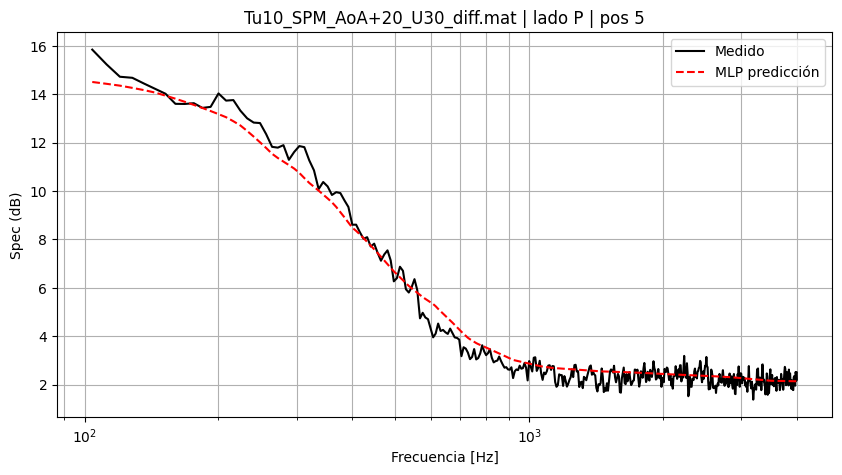

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

dups = df_full.columns[df_full.columns.duplicated()].tolist()
df_full = df_full.loc[:, ~df_full.columns.duplicated(keep="first")]

def _pick_col(df, name):
    if name in df.columns:
        return name
    alt = f"infoaux_{name}"
    if alt in df.columns:
        return alt
    raise KeyError(f"No encontré la columna '{name}' ni '{alt}' en df_full.")

def plot_spectrum_from_row(row_idx):
    c_file = _pick_col(df_full, "filename_diff")
    c_side = _pick_col(df_full, "side")
    c_pos  = _pick_col(df_full, "position")

    row = df_full.iloc[row_idx]
    fname = row[c_file]
    side  = str(row[c_side]).upper()
    pos   = int(row[c_pos])

    mask = (
        (df_full[c_file] == fname) &
        (df_full[c_side].astype(str).str.upper() == side) &
        (df_full[c_pos].astype(int) == pos)
    )

    block = df_full.loc[mask].copy().sort_values("freq")

    freqs     = block["freq"].astype(float).values
    spec_real = block["spec"].astype(float).values

    spec_pred = []
    for _, r in block.iterrows():
        y_hat = predict_spec(
            Ue=float(r["Ue"]),
            dcpdx=float(r["dcpdx"]),
            delta=float(r["delta"]),
            tau_w=float(r["tau_w"]),
            Tu_BL=float(r["Tu_BL"]),
            freq=float(r["freq"]),
            side_str=str(r[c_side]),
            position=int(r[c_pos])
        )
        spec_pred.append(y_hat)

    spec_pred = np.array(spec_pred, dtype=float)

    plt.figure(figsize=(10,5))
    plt.semilogx(freqs, spec_real, "k-", label="Medido")
    plt.semilogx(freqs, spec_pred, "r--", label="MLP predicción")
    plt.xlabel("Frecuencia [Hz]")
    plt.ylabel("Spec (dB)")
    plt.title(f"{fname} | lado {side} | pos {pos}")
    plt.grid(True, which="both")
    plt.legend()
    plt.show()

#Insertar fila
plot_spectrum_from_row(158800)


Grafics completos


In [ ]:
import os
import matplotlib.pyplot as plt
import shutil
import numpy as np
from google.colab import files

# 1. Crear la carpeta para guardar todo temporalmente
carpeta_salida = "Espectros_Exportados"
os.makedirs(carpeta_salida, exist_ok=True)

print(f"Iniciando la exportación de 756 gráficas a '{carpeta_salida}'... Esto tomará unos minutos.")

# 2. Asegurarnos de tener los nombres de las columnas correctos (como en tu código)
def _pick_col_local(df, name):
    if name in df.columns: return name
    alt = f"infoaux_{name}"
    if alt in df.columns: return alt
    return name

c_file = _pick_col_local(df_full, "filename_diff")
c_side = _pick_col_local(df_full, "side")
c_pos = _pick_col_local(df_full, "position")

# 3. Agrupar el dataset por cada curva única (las 756 curvas)
grupos = df_full.groupby([c_file, c_side, c_pos])

contador = 0

for (archivo, lado, pos), grupo in grupos:
    # Ordenar las frecuencias de menor a mayor
    grupo = grupo.sort_values("freq")
    freqs = grupo["freq"].astype(float).values
    real_dB = grupo["spec"].astype(float).values

    # Predecir toda la curva con tu modelo (reutilizando tu lógica)
    pred_dB = []
    for _, row in grupo.iterrows():
        y_hat = predict_spec(
            Ue=float(row["Ue"]), dcpdx=float(row["dcpdx"]), delta=float(row["delta"]),
            tau_w=float(row["tau_w"]), Tu_BL=float(row["Tu_BL"]), freq=float(row["freq"]),
            side_str=str(row[c_side]), position=int(row[c_pos])
        )
        pred_dB.append(y_hat)

    pred_dB = np.array(pred_dB)

    # Generar un nombre de archivo limpio (sin caracteres que rompan la ruta)
    nombre_base = str(archivo).replace('.mat', '').replace('/', '_')
    nombre_grafica = f"{nombre_base}_Lado_{lado}_Pos_{pos}"

    # --- CREAR Y GUARDAR LA GRÁFICA ---
    plt.figure(figsize=(8, 6))

    # Usando el estilo técnico de tus gráficas
    plt.semilogx(freqs, real_dB, 'k', linewidth=2.5, label="Measured")
    plt.semilogx(freqs, pred_dB, 'r--', linewidth=2, label="Predicted")

    # Formato
    plt.xlabel("f [Hz]", fontsize=12)
    plt.ylabel("ΔΦPP [dB]", fontsize=12)
    plt.title(f"Spectrum - {nombre_grafica}", fontsize=10)
    plt.grid(True, which="both", linestyle="--", alpha=0.5)
    plt.legend(fontsize=10)
    plt.tight_layout()

    # Guardar y CERRAR
    ruta_png = os.path.join(carpeta_salida, f"{nombre_grafica}.png")
    plt.savefig(ruta_png, format='png', dpi=150, bbox_inches='tight')
    plt.close() # ¡CRÍTICO para que no se trabe el Colab!

    # Un pequeño contador para saber cómo va el proceso
    contador += 1
    if contador % 50 == 0:
        print(f"Generadas {contador}/756 gráficas...")

print("¡Generación completada exitosamente! Comprimiendo archivo...")
shutil.make_archive("Espectros_Completos", 'zip', carpeta_salida)

print("Iniciando descarga a tu computadora...")
files.download("Espectros_Completos.zip")

Iniciando la exportación de 756 gráficas a 'Espectros_Exportados'... Esto tomará unos minutos.
Generadas 50/756 gráficas...
Generadas 100/756 gráficas...
Generadas 150/756 gráficas...
Generadas 200/756 gráficas...
Generadas 250/756 gráficas...
Generadas 300/756 gráficas...
Generadas 350/756 gráficas...
Generadas 400/756 gráficas...
Generadas 450/756 gráficas...
Generadas 500/756 gráficas...
Generadas 550/756 gráficas...
Generadas 600/756 gráficas...
Generadas 650/756 gráficas...


Generación del code publico

In [ ]:
import torch
import joblib
from google.colab import drive

# 1. Montar (conectar) tu Google Drive
drive.mount('/content/drive')

# 2. Definir la ruta donde se guardarán en tu Drive (puedes cambiar 'Mi unidad' por una carpeta específica si quieres)
ruta_drive = '/content/drive/MyDrive/'
ruta_modelo = ruta_drive + 'modelo_mlp_pesos.pth'
ruta_scaler = ruta_drive + 'scaler_variables.pkl'

# 3. Guardar los archivos directamente en Drive
torch.save(best_state, ruta_modelo)
joblib.dump(scaler, ruta_scaler)

print(f"¡Listo! Archivos guardados de forma segura en tu Google Drive en la ruta: {ruta_drive}")

MessageError: Error: credential propagation was unsuccessful

Analisis de sensitividad


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def analisis_sensibilidad(row_idx, variable_a_perturbar, variaciones=[-0.5, -0.1, 0.0, 0.1, 0.5]):
    """
    Realiza un análisis de sensibilidad sobre una variable específica manteniendo las demás constantes.
    variaciones: lista de porcentajes en formato decimal. 0.0 es Baseline, 0.5 es +50%, etc.
    """
    # 1. Extraer los datos del Caso Base
    row = df_full.iloc[row_idx]

    # Manejo seguro de los nombres de las columnas para filtrar
    c_file = _pick_col(df_full, "filename_diff")
    c_side = _pick_col(df_full, "side")
    c_pos  = _pick_col(df_full, "position")

    fname = row[c_file]
    side = str(row[c_side]).upper()
    pos = int(row[c_pos])

    # 2. Filtrar el bloque completo de frecuencias para este caso
    mask = (
        (df_full[c_file] == fname) &
        (df_full[c_side].astype(str).str.upper() == side) &
        (df_full[c_pos].astype(int) == pos)
    )
    block = df_full.loc[mask].copy().sort_values("freq")
    freqs = block["freq"].astype(float).values

    # 3. Guardar las características físicas base (Intactas)
    base_features = {
        "Ue": float(row["Ue"]),
        "dcpdx": float(row["dcpdx"]),
        "delta": float(row["delta"]),
        "tau_w": float(row["tau_w"]),
        "Tu_BL": float(row["Tu_BL"])
    }

    # Configuración de colores y estilos para la gráfica
    estilos = {
        -0.5: ('--', 'blue', '-50%'),
        -0.1: ('-.', 'deepskyblue', '-10%'),
         0.0: ('-', 'black', 'Baseline (0%)'),
         0.1: ('-.', 'orange', '+10%'),
         0.5: ('--', 'red', '+50%')
    }

    plt.figure(figsize=(12, 7))

    # 4. Iterar sobre cada variación porcentual
    for var in variaciones:
        spec_pred = []
        multiplicador = 1.0 + var  # Ej: 1.0 + (-0.5) = 0.5

        # Iterar sobre todo el rango de frecuencias
        for f in freqs:
            # Copiar las features base y aplicar la perturbación SOLO a la variable elegida
            feats = base_features.copy()
            feats[variable_a_perturbar] = feats[variable_a_perturbar] * multiplicador

            # Predecir con el modelo
            y_hat = predict_spec(
                Ue=feats["Ue"],
                dcpdx=feats["dcpdx"],
                delta=feats["delta"],
                tau_w=feats["tau_w"],
                Tu_BL=feats["Tu_BL"],
                freq=f,
                side_str=side,
                position=pos
            )
            spec_pred.append(y_hat)

        # Graficar la curva resultante
        ls, color, label = estilos[var]
        # Hacemos la línea del Baseline un poco más gruesa
        lw = 2.5 if var == 0.0 else 1.5
        plt.semilogx(freqs, spec_pred, linestyle=ls, color=color, label=f"{label}", linewidth=lw)

    # 5. Formato de la gráfica
    plt.xlabel("f [Hz]", fontsize=12)
    plt.ylabel("ΔΦPP [dB]", fontsize=12)

    plt.grid(True, which="both", linestyle="--", alpha=0.6)
    plt.legend(fontsize=11)
    plt.show()


plt.savefig('graficas_resultados_espectro_analisis_de_sensitividad.pdf', format='pdf', bbox_inches='tight')

plt.show()

<Figure size 640x480 with 0 Axes>

Generando análisis para Ue...


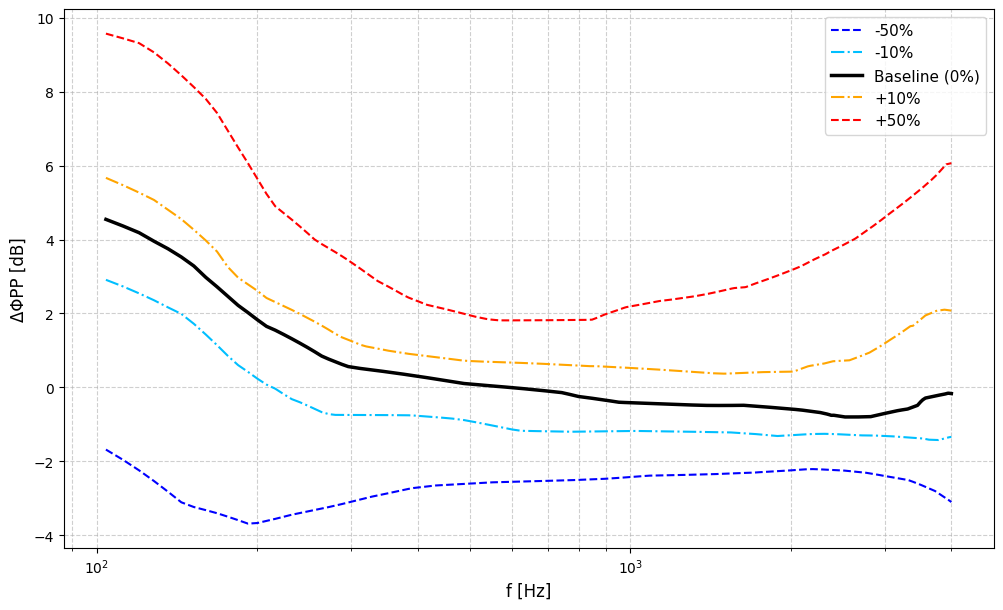

Generando análisis para dcpdx...


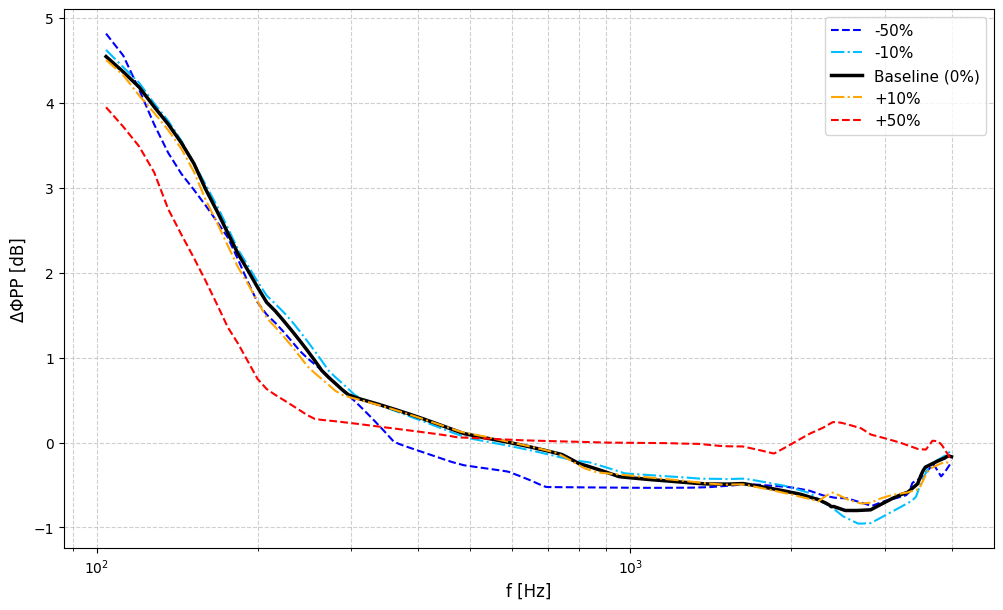

Generando análisis para delta...


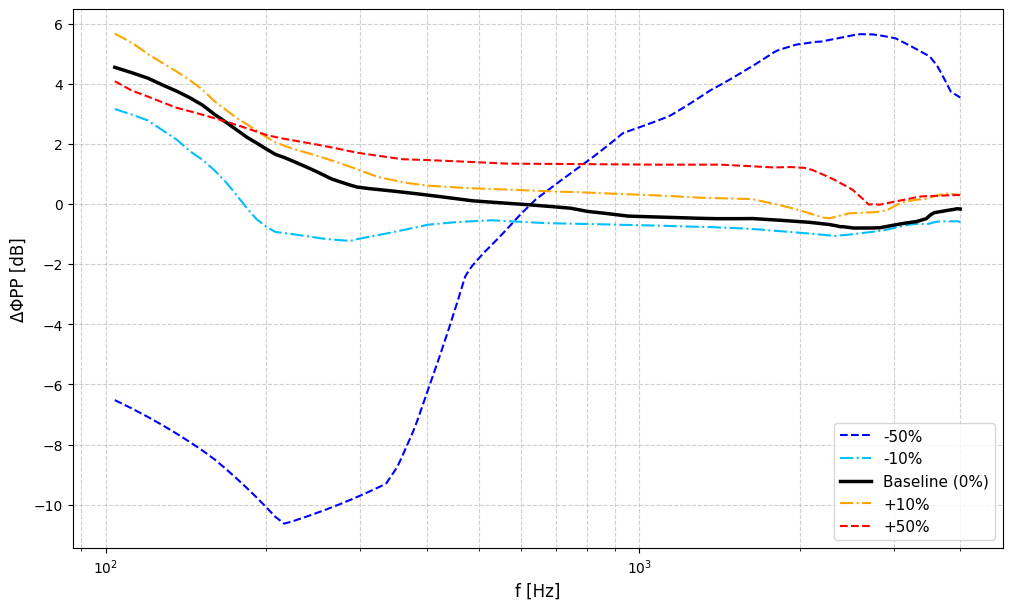

Generando análisis para tau_w...


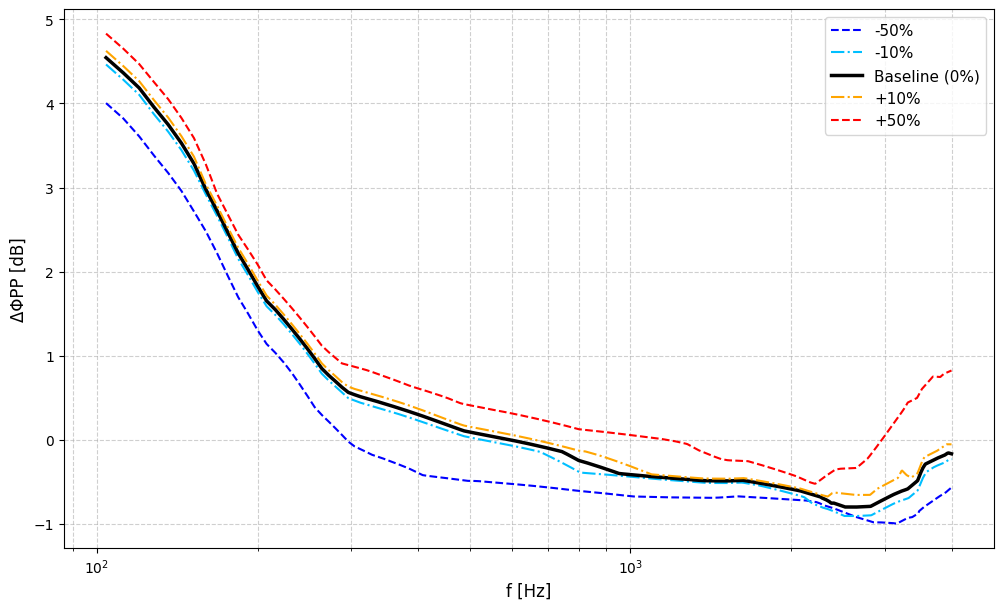

In [ ]:
# Fila - caso
indice_base = 1001

# 1. Sensibilidad a la velocidad local (Ue)
print("Generando análisis para Ue...")
analisis_sensibilidad(indice_base, "Ue")

# 2. Sensibilidad al gradiente de presión (dcpdx)
print("Generando análisis para dcpdx...")
analisis_sensibilidad(indice_base, "dcpdx")

# 3. Sensibilidad al espesor de la capa límite (delta)
print("Generando análisis para delta...")
analisis_sensibilidad(indice_base, "delta")

# 4. Sensibilidad a la tensión de pared (tau_w)
print("Generando análisis para tau_w...")
analisis_sensibilidad(indice_base, "tau_w")



Porcentaje de error calculado con la ecuación establecida

Calculando el error cuadrático integral para 756 curvas. Por favor espera...

AVERAGE ERROR (Error Cuadrático Promedio): 4.08

--- ❌ CURVA CON EL ERROR MÁXIMO (PEOR CASO) ---
Archivo: Tu20_SPM_AoA+60_U10_diff.mat | Lado: P | Pos: 4
Error: 27.25

--- ✅ CURVA CON EL ERROR MÍNIMO (MEJOR CASO) ---
Archivo: Tu10_AoA+00_U15_diff.mat | Lado: P | Pos: 4
Error: 0.25


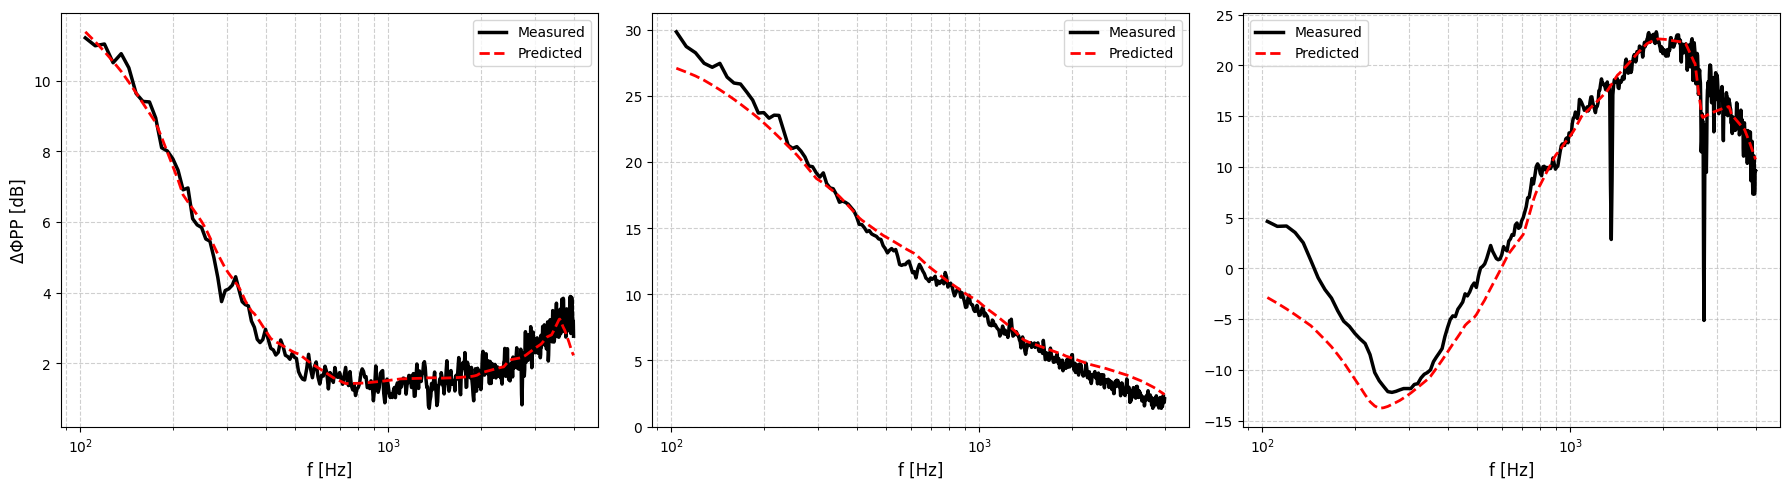

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import trapezoid  # Usamos esto para evitar el texto rojo de advertencia

# 1. Asegurarnos de tener los nombres de las columnas correctos
c_file = _pick_col(df_full, "filename_diff")
c_side = _pick_col(df_full, "side")
c_pos  = _pick_col(df_full, "position")

resultados_error = []

# 2. Agrupar el dataset por cada curva única
grupos = df_full.groupby([c_file, c_side, c_pos])

print(f"Calculando el error cuadrático integral para {len(grupos)} curvas. Por favor espera...")

for (archivo, lado, pos), grupo in grupos:
    # Ordenar las frecuencias de menor a mayor
    grupo = grupo.sort_values("freq")
    freqs = grupo["freq"].astype(float).values
    real_dB = grupo["spec"].astype(float).values

    # Predecir toda la curva con tu modelo
    pred_dB = []
    for _, row in grupo.iterrows():
        y_hat = predict_spec(
            Ue=float(row["Ue"]), dcpdx=float(row["dcpdx"]), delta=float(row["delta"]),
            tau_w=float(row["tau_w"]), Tu_BL=float(row["Tu_BL"]), freq=float(row["freq"]),
            side_str=str(row[c_side]), position=int(row[c_pos])
        )
        pred_dB.append(y_hat)
    pred_dB = np.array(pred_dB)

    # --- APLICACIÓN DE TU ECUACIÓN EXACTA ---
    # Integrando: (1/f) * (specMedido - specModelo)^2
    integrando = (1.0 / freqs) * (real_dB - pred_dB)**2

    # Integral con respecto a f (df)
    integral_val = trapezoid(integrando, x=freqs)

    # Denominador: log10(fmax/f0)  (Nota: si tu profe usa logaritmo natural, cambia np.log10 por np.log)
    denominador = np.log10(freqs[-1] / freqs[0])

    # Error final de esta curva
    error_curva = integral_val / denominador

    # Guardar el resultado
    resultados_error.append({
        'Archivo': archivo,
        'Lado': lado,
        'Posición': pos,
        'Error': error_curva
    })

# 3. Convertir a tabla para analizar los extremos
df_errores = pd.DataFrame(resultados_error)

# Calcular métricas finales
error_promedio = df_errores['Error'].mean()
curva_max = df_errores.loc[df_errores['Error'].idxmax()]
curva_min = df_errores.loc[df_errores['Error'].idxmin()]

# Buscar el caso mediano (típico)
mediana_error = df_errores['Error'].median()
df_errores['Distancia_Mediana'] = np.abs(df_errores['Error'] - mediana_error)
curva_tipica = df_errores.loc[df_errores['Distancia_Mediana'].idxmin()]

# --- IMPRESIÓN DE RESULTADOS ---
print("\n" + "="*50)
print(f"AVERAGE ERROR (Error Cuadrático Promedio): {error_promedio:.2f}")
print("="*50)

print("\n--- ❌ CURVA CON EL ERROR MÁXIMO (PEOR CASO) ---")
print(f"Archivo: {curva_max['Archivo']} | Lado: {curva_max['Lado']} | Pos: {curva_max['Posición']}")
print(f"Error: {curva_max['Error']:.2f}")

print("\n--- ✅ CURVA CON EL ERROR MÍNIMO (MEJOR CASO) ---")
print(f"Archivo: {curva_min['Archivo']} | Lado: {curva_min['Lado']} | Pos: {curva_min['Posición']}")
print(f"Error: {curva_min['Error']:.2f}")

# --- 4. GRÁFICAS PARA EL PAPER ---
casos_a_graficar = [
    ("✅ MEJOR CASO (Mínimo)", curva_min),
    ("📊 CASO TÍPICO (Mediana)", curva_tipica),
    ("❌ PEOR CASO (Máximo)", curva_max)
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (titulo, datos_curva) in zip(axes, casos_a_graficar):
    archivo = datos_curva['Archivo']
    lado = datos_curva['Lado']
    pos = datos_curva['Posición']
    error_val = datos_curva['Error']

    mask = (df_full[c_file] == archivo) & (df_full[c_side] == lado) & (df_full[c_pos] == pos)
    grupo = df_full[mask].sort_values("freq")

    freqs = grupo["freq"].astype(float).values
    real_dB = grupo["spec"].astype(float).values

    pred_dB = []
    for _, row in grupo.iterrows():
        y_hat = predict_spec(
            Ue=float(row["Ue"]), dcpdx=float(row["dcpdx"]), delta=float(row["delta"]),
            tau_w=float(row["tau_w"]), Tu_BL=float(row["Tu_BL"]), freq=float(row["freq"]),
            side_str=str(lado), position=int(pos)
        )
        pred_dB.append(y_hat)

    ax.semilogx(freqs, real_dB, 'k-', linewidth=2.5, label="Measured")
    ax.semilogx(freqs, pred_dB, 'r--', linewidth=2, label="Predicted")


    ax.set_xlabel("f [Hz]", fontsize=12)
    if ax == axes[0]:
        ax.set_ylabel("ΔΦPP [dB]", fontsize=12)
    ax.grid(True, which="both", linestyle="--", alpha=0.6)
    ax.legend()

plt.tight_layout()
plt.show()

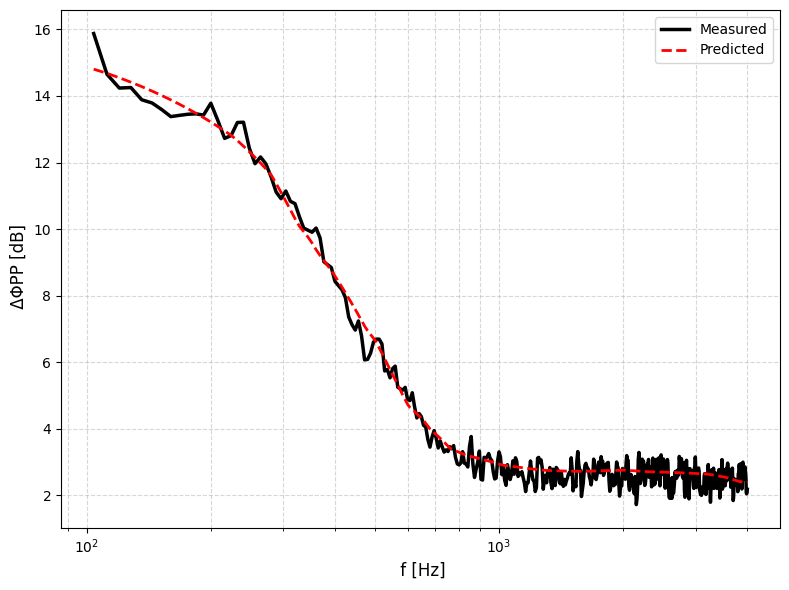

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

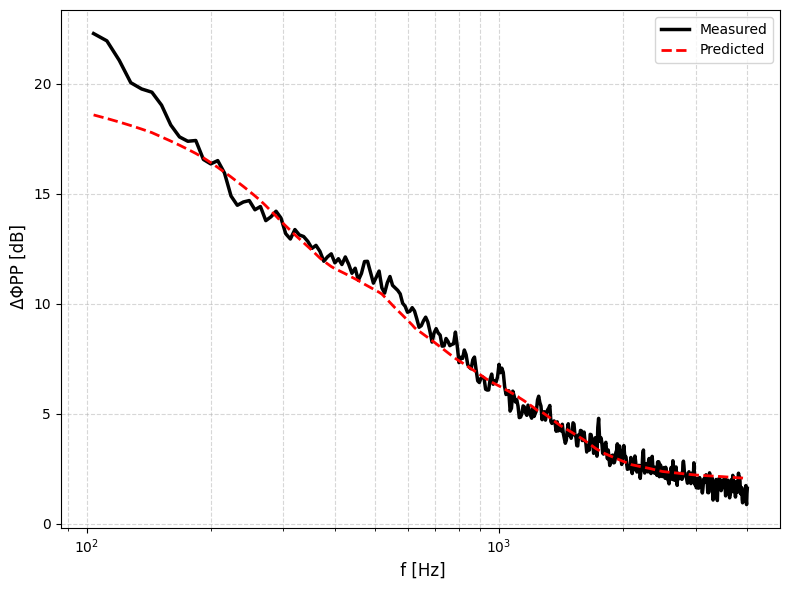

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

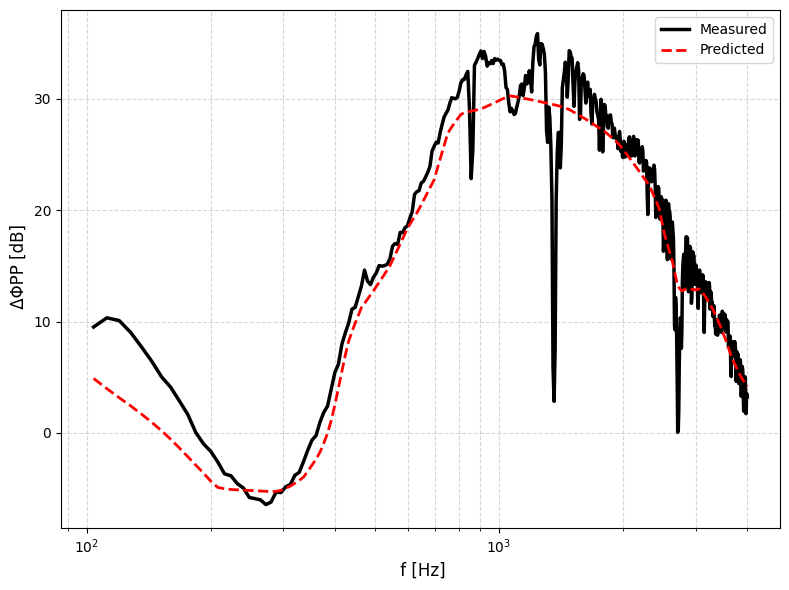

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import matplotlib.pyplot as plt
from google.colab import files

casos = [
    ("Mejor Caso (Mínimo)", curva_min, "mejor_caso.pdf"),
    ("Caso Típico (Mediana)", curva_tipica, "caso_tipico.pdf"),
    ("Peor Caso (Máximo)", curva_max, "peor_caso.pdf")
]

for titulo, datos_curva, nombre_archivo in casos:
    plt.figure(figsize=(8, 6))

    archivo = datos_curva['Archivo']
    lado = datos_curva['Lado']
    pos = datos_curva['Posición']
    error_val = datos_curva['Error']

    # Filtrar y predecir
    mask = (df_full[c_file] == archivo) & (df_full[c_side] == lado) & (df_full[c_pos] == pos)
    grupo = df_full[mask].sort_values("freq")
    freqs = grupo["freq"].astype(float).values
    real_dB = grupo["spec"].astype(float).values

    pred_dB = []
    for _, row in grupo.iterrows():
        y_hat = predict_spec(
            Ue=float(row["Ue"]), dcpdx=float(row["dcpdx"]), delta=float(row["delta"]),
            tau_w=float(row["tau_w"]), Tu_BL=float(row["Tu_BL"]), freq=float(row["freq"]),
            side_str=str(lado), position=int(pos)
        )
        pred_dB.append(y_hat)

    # Graficar con símbolos técnicos
    plt.semilogx(freqs, real_dB, 'k-', linewidth=2.5, label="Measured")
    plt.semilogx(freqs, pred_dB, 'r--', linewidth=2, label="Predicted")

    # Personalización

    plt.xlabel(" f [Hz]", fontsize=12)
    plt.ylabel(" ΔΦPP [dB]", fontsize=12) # PSD: Power Spectral Density
    plt.grid(True, which="both", linestyle="--", alpha=0.5)
    plt.legend(fontsize=10)


    plt.tight_layout()
    plt.savefig(nombre_archivo, format='pdf', bbox_inches='tight')
    plt.show()

    # Descargar automáticamente
    files.download(nombre_archivo)

In [ ]:
# Crear la tabla de resumen
tabla_resumen = pd.DataFrame({
    'Metric': ['Average Error (Integral)', 'Maximum Error (Worst Case)', 'Minimum Error (Best Case)'],
    'Value': [f"{error_promedio:.4f}", f"{curva_max['Error']:.4f}", f"{curva_min['Error']:.4f}"],
    'Case Details': [
        'All test samples (756 curves)',
        f"{curva_max['Archivo'].split('_diff')[0]} | Lado {curva_max['Lado']} | Pos {curva_max['Posición']}",
        f"{curva_min['Archivo'].split('_diff')[0]} | Lado {curva_min['Lado']} | Pos {curva_min['Posición']}"
    ]
})

print("\nTABLA DE RESULTADOS PARA EL PAPER:")
display(tabla_resumen)

# Opcional: exportar tabla a Excel para mayor facilidad
tabla_resumen.to_excel("tabla_resultados_mlp.xlsx", index=False)
files.download("tabla_resultados_mlp.xlsx")


TABLA DE RESULTADOS PARA EL PAPER:


,Metric,Value,Case Details
0,Average Error (Integral),3.9660,All test samples (756 curves)
1,Maximum Error (Worst Case),29.0538,Tu10_SPM_AoA+70_U10 | Lado P | Pos 4
2,Minimum Error (Best Case),0.2802,Tu10_SPM_AoA+10_U30 | Lado P | Pos 5


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

70/30

In [ ]:
from sklearn.model_selection import train_test_split

# 1. Crear una columna nueva vacía en el dataset original
df_full['Set_Modelo'] = 'Desconocido'

# 2. Replicar la partición (split)
# IMPORTANTE: Cambia el 'random_state=42' por el número exacto que usaste
# cuando entrenaste el MLP originalmente (suele ser 42, 0, o 123).
indices = df_full.index
train_idx, test_idx = train_test_split(indices, test_size=0.3, random_state=42)

# 3. Etiquetar las filas usando los índices
df_full.loc[train_idx, 'Set_Modelo'] = 'Entrenamiento (70%)'
df_full.loc[test_idx, 'Set_Modelo'] = 'Prueba (30%)'

print("¡Etiquetado completado! Tu dataset ahora tiene la columna 'Set_Modelo'.")

# --- HERRAMIENTA DE AUDITORÍA ---
# Usa esto para buscar en qué grupo cayó una curva específica.
# Por ejemplo, busquemos tu PEOR CASO (AoA+70) o MEJOR CASO.

archivo_a_buscar = "Tu20_SPM_AoA+70_U10_diff.mat" # Cambia por el archivo que quieras verificar
lado_a_buscar = "P"
pos_a_buscar = 4

mask = (df_full[c_file] == archivo_a_buscar) & \
       (df_full[c_side] == lado_a_buscar) & \
       (df_full[c_pos] == pos_a_buscar)

resultado = df_full[mask]

if not resultado.empty:
    print(f"\n🔍 RESULTADOS PARA LA CURVA: {archivo_a_buscar} | Lado: {lado_a_buscar} | Pos: {pos_a_buscar}")
    # Como una curva tiene varios puntos (frecuencias), miramos el conteo
    conteo_sets = resultado['Set_Modelo'].value_counts()
    print("Distribución de los puntos de esta curva:")
    print(conteo_sets)
else:
    print("\nNo se encontró esa curva. Verifica los nombres.")

¡Etiquetado completado! Tu dataset ahora tiene la columna 'Set_Modelo'.


NameError: name 'c_file' is not defined

In [ ]:
from sklearn.model_selection import train_test_split

# 1. Ingresa aquí el número de la fila que quieres consultar
numero_de_fila = 10000  # <-- CAMBIA ESTE NÚMERO POR EL TUYO

# 2. Replicar la partición exacta
# (Asegúrate de que el random_state sea el mismo que usaste al entrenar el MLP)
indices = df_full.index
train_idx, test_idx = train_test_split(indices, test_size=0.3, random_state=42)

# 3. Comprobar a qué grupo pertenece la fila
if numero_de_fila in train_idx:
    print(f"✅ La fila {numero_de_fila} hizo parte del ENTRENAMIENTO (70%).")
    print("   (El modelo 'memorizó' o vio este dato al ajustarse).")
elif numero_de_fila in test_idx:
    print(f"🧪 La fila {numero_de_fila} hizo parte de la PRUEBA / TEST (30%).")
    print("   (Es un dato completamente nuevo y desconocido para el modelo).")
else:
    print(f"❌ La fila {numero_de_fila} no existe en los índices del dataset.")

NameError: name 'df_full' is not defined